In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
plt.style.use("ggplot")

In [2]:
df = pd.read_csv("cleaned_dataset.csv")
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,Month,WeekendOrder,DiscountUsed,RevenuePerItem
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10,January,False,1,570.62
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70,August,False,1,151.35
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40,February,False,1,550.68
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19,October,True,1,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04,May,False,1,626.01


In [3]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)
print("\nData Types:")
print(df.dtypes)

Shape: (1200, 18)

Columns:
Index(['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice',
       'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber',
       'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice', 'Month',
       'WeekendOrder', 'DiscountUsed', 'RevenuePerItem'],
      dtype='str')

Data Types:
OrderID                str
Date                   str
CustomerID             str
Product                str
Quantity             int64
UnitPrice          float64
ShippingAddress        str
PaymentMethod          str
OrderStatus            str
TrackingNumber         str
ItemsInCart          int64
CouponCode             str
ReferralSource         str
TotalPrice         float64
Month                  str
WeekendOrder          bool
DiscountUsed         int64
RevenuePerItem     float64
dtype: object


In [4]:
df.select_dtypes(include=["number", "bool"]).columns

Index(['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice', 'WeekendOrder',
       'DiscountUsed', 'RevenuePerItem'],
      dtype='str')

In [5]:
features = [
    "Quantity",
    "UnitPrice",
    "ItemsInCart",
    "TotalPrice",
    "WeekendOrder",
    "DiscountUsed",
    "RevenuePerItem"
]
X = df[features].copy()
X.head()

,Quantity,UnitPrice,ItemsInCart,TotalPrice,WeekendOrder,DiscountUsed,RevenuePerItem
0,5,570.62,7,2853.10,False,1,570.62
1,2,151.35,3,302.70,False,1,151.35
2,5,550.68,8,2753.40,False,1,550.68
3,1,273.19,5,273.19,True,1,273.19
4,4,626.01,8,2504.04,False,1,626.01


In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=features)
X_scaled.head()

,Quantity,UnitPrice,ItemsInCart,TotalPrice,WeekendOrder,DiscountUsed,RevenuePerItem
0,1.459993,1.086822,0.664173,2.195362,-0.652057,0.588898,1.086822
1,-0.672248,-1.040426,-1.089419,-0.916723,-0.652057,0.588898,-1.040426
2,1.459993,0.985653,1.102571,2.073705,-0.652057,0.588898,0.985653
3,-1.382995,-0.422247,-0.212623,-0.952732,1.533609,0.588898,-0.422247
4,0.749246,1.367855,1.102571,1.769427,-0.652057,0.588898,1.367855


In [7]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)
explained_variance = pd.DataFrame({
    "Principal Component": range(1, len(pca.explained_variance_ratio_) + 1),
    "Explained Variance": pca.explained_variance_ratio_,
    "Cumulative Variance": np.cumsum(pca.explained_variance_ratio_)
})
explained_variance

,Principal Component,Explained Variance,Cumulative Variance
0,1,0.398500,0.398500
1,2,0.249499,0.647999
2,3,0.145211,0.793210
3,4,0.139497,0.932708
4,5,0.057120,0.989827
5,6,0.010173,1.000000
6,7,0.000000,1.000000


We decide to retain components to display 90-95% of the variance which falls at the 4 components mark (~93.27%).

In [8]:
pca = PCA(n_components=4)
X_pca = pca.fit_transform(X_scaled)
X_pca = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2", "PC3", "PC4"]
)
X_pca.head()

,PC1,PC2,PC3,PC4
0,2.970478,0.729604,-0.008906,0.819308
1,-2.023941,-0.434431,-0.140063,0.904745
2,2.896399,1.047806,0.025534,0.836909
3,-1.450508,-0.880990,1.464713,-0.588935
4,2.918671,0.305814,-0.025831,0.817496


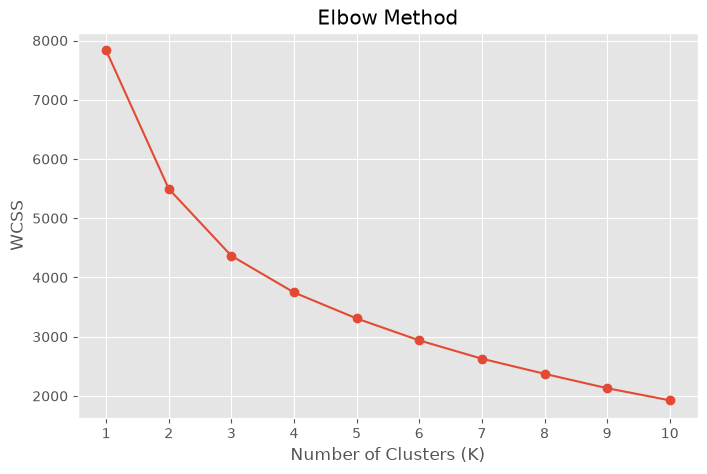

In [9]:
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_pca)
    wcss.append(kmeans.inertia_)
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.xticks(range(1, 11))
plt.show()

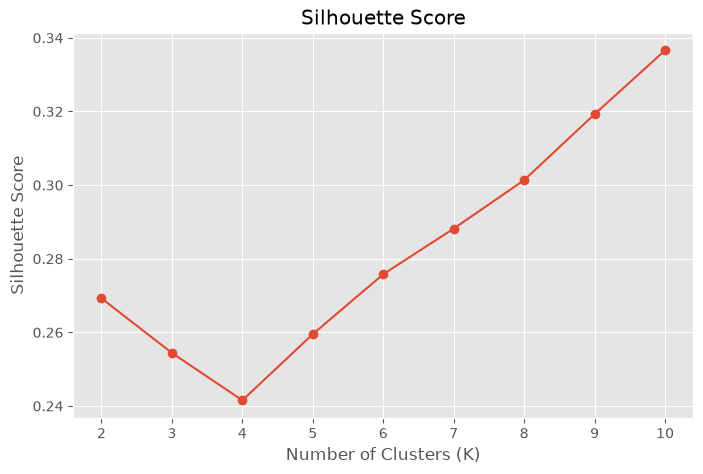

    K  Silhouette Score
0   2          0.269250
1   3          0.254402
2   4          0.241535
3   5          0.259535
4   6          0.275797
5   7          0.288187
6   8          0.301366
7   9          0.319288
8  10          0.336615


In [10]:
silhouette_scores = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    silhouette_scores.append(score)
plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), silhouette_scores, marker="o")
plt.title("Silhouette Score")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.xticks(range(2, 11))
plt.show()

print(pd.DataFrame({
    "K": range(2, 11),
    "Silhouette Score": silhouette_scores
}))

Even though the Silhouette Score is highest at K = 10 we decide to choose K = 4 (using the Elbow Method) since K = 4 is a more practical choice.

In [11]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X_pca)
df[["CustomerID", "Cluster"]].head()

,CustomerID,Cluster
0,C72649,3
1,C75739,0
2,C81728,3
3,C33540,0
4,C81840,3


In [12]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X_pca)
df[["CustomerID", "Cluster"]].head()

,CustomerID,Cluster
0,C72649,3
1,C75739,0
2,C81728,3
3,C33540,0
4,C81840,3


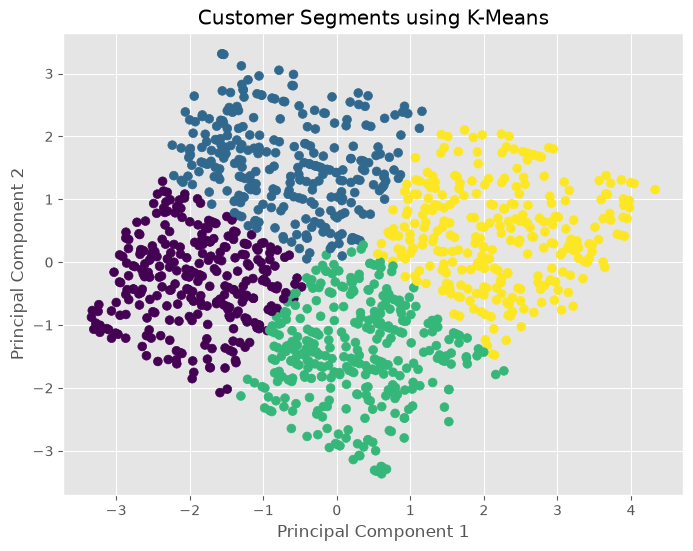

In [13]:
plt.figure(figsize=(8, 6))
plt.scatter(
    X_pca["PC1"],
    X_pca["PC2"],
    c=df["Cluster"],
    cmap="viridis",
    s=40
)
plt.title("Customer Segments using K-Means")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

In [14]:
cluster_summary = df.groupby("Cluster")[features].mean().round(2)
cluster_summary

,Quantity,UnitPrice,ItemsInCart,TotalPrice,WeekendOrder,DiscountUsed,RevenuePerItem
Cluster,,,,,,,
0,1.79,166.41,3.99,292.88,0.34,0.75,166.41
1,4.17,188.64,7.21,776.23,0.28,0.70,188.64
2,1.83,499.02,3.92,895.27,0.29,0.76,499.02
3,4.16,540.00,7.05,2230.77,0.29,0.76,540.00


In [15]:
persona_map = {
    0: "Budget Customers",
    1: "Bulk Customers",
    2: "Premium Customers",
    3: "High-Value Customers"
}
df["Customer Persona"] = df["Cluster"].map(persona_map)
df[["CustomerID", "Cluster", "Customer Persona"]].head()

,CustomerID,Cluster,Customer Persona
0,C72649,3,High-Value Customers
1,C75739,0,Budget Customers
2,C81728,3,High-Value Customers
3,C33540,0,Budget Customers
4,C81840,3,High-Value Customers


In [16]:
df["Customer Persona"].value_counts()

Customer Persona
Premium Customers       332
High-Value Customers    298
Budget Customers        289
Bulk Customers          281
Name: count, dtype: int64

In [17]:
df.to_csv("customer_segmentation_results.csv", index=False)

# Conclusion

In this project, customer segmentation was performed using K-Means Clustering.
This was achieved using:
- Selecting important features from the dataset
- Standardizing the data using StandardScaler
- Reducing number of input points using PCA
- Finding the ideal number of clusters using the Elbow Method and Silhouette Score
- Applying K-Means clustering
- Visualizing customer segments
- Interpreting clusters as business personas

The final model identified four meaningful customer segments:
- Premium Customers       (332)
- High-Value Customers    (298)
- Budget Customers        (289)
- Bulk Customers          (281)



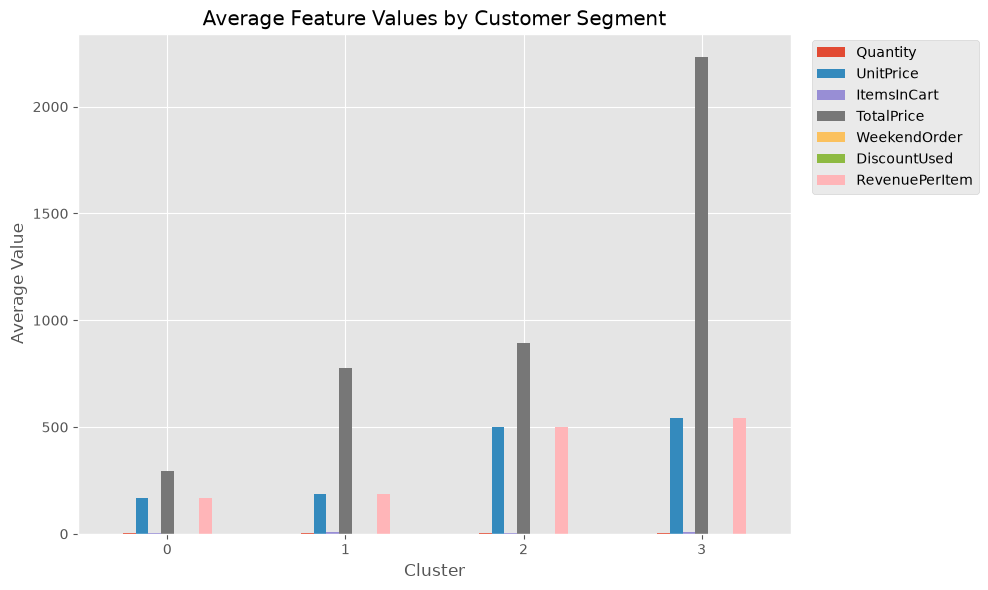

In [18]:
cluster_summary.plot(kind="bar", figsize=(10, 6))
plt.title("Average Feature Values by Customer Segment")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()